In [51]:
import sys
import os
sys.path.append("../")
sys.path.append("../..")

In [52]:
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [53]:
from scale_rl.common.wandb_utils import *

In [54]:
from color import METHOD_COLORS, METHOD_BOUNDARY_COLORS

In [55]:
from scale_rl.envs.mujoco import MUJOCO_ALL, MUJOCO_RANDOM_SCORE, MUJOCO_TD3_SCORE
from scale_rl.envs.dmc import DMC_EASY_MEDIUM, DMC_HARD
from scale_rl.envs.humanoid_bench import HB_LOCOMOTION_NOHAND, HB_SUCCESS_SCORE
from scale_rl.envs.myosuite import MYOSUITE_TASKS

def replace_hypen_to_underbar(env_name_list):
    for idx in range(len(env_name_list)):
        env_name_list[idx] = env_name_list[idx].replace('-', '_')
    return env_name_list

In [56]:
td7_eval_df = pd.read_csv('../../results/td7.csv', index_col=0)
sac_simba_eval_df = pd.read_csv('../../results/1219_sac_simba_1m.csv', index_col=0) # pd.read_csv('../../results/sac_simba.csv', index_col=0)
tdmpc2_eval_df = pd.read_csv('../../results/tdmpc2.csv', index_col=0)
dreamerv3_eval_df = pd.read_csv('../../results/dreamerv3.csv', index_col=0)

In [57]:
sac_simba_eval_df['exp_name'] = 'Simba'
sac_simba_eval_df

,exp_name,env_name,seed,metric,env_step,value
0,Simba,Humanoid-v4,9000,avg_return,0.0,158.084484
1,Simba,Humanoid-v4,9000,avg_return,50000.0,919.968914
2,Simba,Humanoid-v4,9000,avg_return,100000.0,6104.829226
3,Simba,Humanoid-v4,9000,avg_return,150000.0,2061.806108
4,Simba,Humanoid-v4,9000,avg_return,200000.0,5229.141110
...,...,...,...,...,...,...
27685,Simba,humanoid-stand,500,avg_success,800000.0,0.000000
27686,Simba,humanoid-stand,500,avg_success,850000.0,0.000000
27687,Simba,humanoid-stand,500,avg_success,900000.0,0.000000
27688,Simba,humanoid-stand,500,avg_success,950000.0,0.000000


In [58]:
tdmpc2_eval_df['exp_name'] = 'TD-MPC2'
tdmpc2_eval_df

,exp_name,env_name,seed,metric,env_step,value
82,TD-MPC2,acrobot-swingup,1,avg_return,0.0,7.6
83,TD-MPC2,acrobot-swingup,1,avg_return,100000.0,112.1
84,TD-MPC2,acrobot-swingup,1,avg_return,200000.0,219.4
85,TD-MPC2,acrobot-swingup,1,avg_return,300000.0,350.9
86,TD-MPC2,acrobot-swingup,1,avg_return,400000.0,283.2
...,...,...,...,...,...,...
11900,TD-MPC2,walker-walk-backwards,3,avg_return,3600000.0,980.3
11901,TD-MPC2,walker-walk-backwards,3,avg_return,3700000.0,978.1
11902,TD-MPC2,walker-walk-backwards,3,avg_return,3800000.0,984.8
11903,TD-MPC2,walker-walk-backwards,3,avg_return,3900000.0,986.1


In [59]:
dreamerv3_eval_df['exp_name'] = 'DreamerV3'
dreamerv3_eval_df

,exp_name,env_name,seed,metric,env_step,value
0,DreamerV3,acrobot_swingup,1,avg_return,0,13.120669
1,DreamerV3,acrobot_swingup,1,avg_return,50000,112.592280
2,DreamerV3,acrobot_swingup,1,avg_return,100000,115.139457
3,DreamerV3,acrobot_swingup,1,avg_return,150000,150.760142
4,DreamerV3,acrobot_swingup,1,avg_return,200000,142.569552
...,...,...,...,...,...,...
4048,DreamerV3,walker_walk,3,avg_return,300000,925.014982
4049,DreamerV3,walker_walk,3,avg_return,350000,936.634629
4050,DreamerV3,walker_walk,3,avg_return,400000,792.896831
4051,DreamerV3,walker_walk,3,avg_return,450000,938.021900


In [60]:
simba_color = METHOD_BOUNDARY_COLORS["Simba"] # sns.color_palette("YlOrBr",20)[8]
simba_alpha_color = METHOD_COLORS["Simba"] # (*simba_color, 0.2)
tdmpc2_color = METHOD_BOUNDARY_COLORS["TD-MPC2"] # sns.color_palette("RdPu",20)[7]
tdmpc2_alpha_color = METHOD_COLORS["TD-MPC2"] # (*tdmpc2_color, 0.2)
td7_color = METHOD_BOUNDARY_COLORS["TD7"] # sns.color_palette("Blues",20)[8]
td7_alpha_color = METHOD_COLORS["TD7"] # (*td7_color, 0.2)
dreamerv3_color = METHOD_BOUNDARY_COLORS["DreamerV3"] # sns.color_palette("Purples",20)[9]
dreamerv3_alpha_color = METHOD_COLORS["DreamerV3"] # (*dreamerv3_color, 0.2)
colors = {
    'Simba': simba_color, 
    'TD7': td7_color, 
    'TD-MPC2': tdmpc2_color,
    'DreamerV3': dreamerv3_color, 
}

In [61]:
simba_marker = '*'
tdmpc2_marker = 's'
td7_marker = '^'
dreamerv3_marker = 'D'
markers = {
    'Simba': simba_marker, 
    'TD7': td7_marker, 
    'TD-MPC2': tdmpc2_marker,
    'DreamerV3': dreamerv3_marker, 
}

In [62]:
import matplotlib.lines as mlines
simba_legend = mlines.Line2D([], [], color=simba_alpha_color, markeredgecolor=simba_color, marker=simba_marker, linestyle='None', markersize=18, label='Simba')
tdmpc2_legend = mlines.Line2D([], [], color=tdmpc2_alpha_color, markeredgecolor=tdmpc2_color, marker=tdmpc2_marker, linestyle='None', markersize=14, label='TD-MPC2')
dreamerv3_legend = mlines.Line2D([], [], color=dreamerv3_alpha_color, markeredgecolor=dreamerv3_color, marker=dreamerv3_marker, linestyle='None', markersize=14, label='DreamerV3')
td7_legend = mlines.Line2D([], [], color=td7_alpha_color, markeredgecolor=td7_color, marker=td7_marker, linestyle='None', markersize=14, label='TD7')

legend_handles = {
    'Simba': simba_legend, 
    'TD7': td7_legend, 
    'TD-MPC2': tdmpc2_legend,
    'DreamerV3': dreamerv3_legend, 
}

In [63]:
FONT_SIZE = 18

#### Collection

In [64]:
MUJOCO_ALL = replace_hypen_to_underbar(MUJOCO_ALL)
DMC_EASY_MEDIUM = replace_hypen_to_underbar(DMC_EASY_MEDIUM)
DMC_HARD = replace_hypen_to_underbar(DMC_HARD)
HB_LOCOMOTION_NOHAND = replace_hypen_to_underbar(HB_LOCOMOTION_NOHAND)
MYOSUITE_TASKS = replace_hypen_to_underbar(MYOSUITE_TASKS)
DMC_ALL = [*DMC_EASY_MEDIUM, *DMC_HARD]

# Remove manipulation & with-hand tasks
HB_SUCCESS_SCORE = {k: v for k, v in HB_SUCCESS_SCORE.items() if k in HB_LOCOMOTION_NOHAND}

In [65]:
eval_df = pd.concat([
    td7_eval_df,
    sac_simba_eval_df, 
    tdmpc2_eval_df,
    dreamerv3_eval_df,
    ], ignore_index=True, sort=False)
eval_df['env_name'] = eval_df['env_name'].str.replace('-', '_')
eval_df

,exp_name,env_name,seed,metric,env_step,value
0,TD7,acrobot_swingup,1,avg_return,25000.0,2.128031
1,TD7,acrobot_swingup,1,avg_return,50000.0,0.077322
2,TD7,acrobot_swingup,1,avg_return,75000.0,30.068576
3,TD7,acrobot_swingup,1,avg_return,100000.0,69.333976
4,TD7,acrobot_swingup,1,avg_return,125000.0,46.783220
...,...,...,...,...,...,...
56831,DreamerV3,walker_walk,3,avg_return,300000.0,925.014982
56832,DreamerV3,walker_walk,3,avg_return,350000.0,936.634629
56833,DreamerV3,walker_walk,3,avg_return,400000.0,792.896831
56834,DreamerV3,walker_walk,3,avg_return,450000.0,938.021900


In [66]:
exp_names = eval_df['exp_name'].unique()
exp_names

array(['TD7', 'Simba', 'TD-MPC2', 'DreamerV3'], dtype=object)

In [67]:
env_names = eval_df['env_name'].unique()
env_names

array(['acrobot_swingup', 'cartpole_balance', 'cartpole_balance_sparse',
       'cartpole_swingup', 'cartpole_swingup_sparse', 'cheetah_run',
       'dog_run', 'dog_stand', 'dog_trot', 'dog_walk', 'finger_spin',
       'finger_turn_easy', 'finger_turn_hard', 'fish_swim',
       'h1_balance_hard_v0', 'h1_balance_simple_v0', 'h1_crawl_v0',
       'h1_hurdle_v0', 'h1_maze_v0', 'h1_pole_v0', 'h1_reach_v0',
       'h1_run_v0', 'h1_sit_hard_v0', 'h1_sit_simple_v0', 'h1_slide_v0',
       'h1_stair_v0', 'h1_stand_v0', 'h1_walk_v0', 'hopper_hop',
       'hopper_stand', 'humanoid_run', 'humanoid_stand', 'humanoid_walk',
       'myo_key_turn', 'myo_key_turn_hard', 'myo_obj_hold',
       'myo_obj_hold_hard', 'myo_pen_twirl', 'myo_pen_twirl_hard',
       'myo_pose', 'myo_pose_hard', 'myo_reach', 'myo_reach_hard',
       'pendulum_swingup', 'quadruped_run', 'quadruped_walk',
       'reacher_easy', 'reacher_hard', 'walker_run', 'walker_stand',
       'walker_walk', 'Humanoid_v4', 'Ant_v4', 'Walker2d_

### Visualization

In [68]:
MUJ_STEPS = 1000000 # 1M
DMC_STEPS = 1000000 # 1M
MYO_STEPS = 1000000 # 1M
HB_STEPS = 1000000 # 1M

In [69]:
def normalize_values(df, TASK_SUCCESS_SCORE):
    """
    Normalize the 'value' column in the DataFrame based on the TASK_SUCCESS_SCORE.

    Args:
    - df (pandas.DataFrame): Input DataFrame with columns 'env_name' and 'value'

    Returns:
    - pandas.DataFrame: DataFrame with normalized 'value' column
    """
    # Create a copy of the DataFrame to avoid modifying the original
    df_normalized = df.copy()

    # Define a function to normalize a single value
    def normalize_value(row):
        env_name = row["env_name"]
        value = row["value"]
        if env_name in TASK_SUCCESS_SCORE:
            return value / TASK_SUCCESS_SCORE[env_name] * 1000
        else:
            print(
                f"Warning: No normalization score found for environment '{env_name}'. Returning original value."
            )
            raise NotImplementedError

    # Apply the normalization function to each row
    df_normalized["value"] = df_normalized.apply(normalize_value, axis=1)

    return df_normalized

In [70]:
def plot_multiple_environment_metrics(
    env_dfs,
    env_names,
    colors,
    metrics,
    x_lim_mins,
    x_lim_maxs,
    y_lim_mins,
    y_lim_maxs,
    y_labels,
    custom_titles,
    plot_width: int = 24,
    plot_height: int = 5,
    num_x_ticks: int = 5,
    x_label: str = "Env steps (M)",
    line_width: float = 2.5
):
    num_envs = len(env_dfs)
    # Set up the figure
    sns.set_style('darkgrid', {"axes.facecolor": "whitesmoke", "grid.color": "gray"})
    # sns.set_style('whitegrid')    
    
    fig, axs = plt.subplots(1, num_envs, figsize=(plot_width, plot_height), squeeze=False)
    axs = axs.flatten()  # Flatten in case of a single subplot

    all_experiments = set()

    for i, (env_df, env_name) in enumerate(zip(env_dfs, env_names)):
        ax = axs[i]
        metric = metrics[i]
        x_lim_min = x_lim_mins[i]
        x_lim_max = x_lim_maxs[i]
        y_lim_min = y_lim_mins[i]
        y_lim_max = int(np.ceil(y_lim_maxs[i]))  # Round up to nearest integer

        env_df = env_df[env_df["metric"] == metric]
        experiments = env_df["exp_name"].unique()
        
        # custom
        experiments = ['Simba', 'BRO', 'TD-MPC2', 'TD7', 'DreamerV3', 'SAC']
        
        all_experiments.update(experiments)

        for exp in experiments:
            exp_data = env_df[env_df["exp_name"] == exp]
            if len(exp_data) == 0:
                continue
            num_seeds = exp_data["seed"].nunique()
            
            # Check if env_step = 0 exists, if not, add it with value 0
            if 0 not in exp_data["env_step"].values:
                zero_row = pd.DataFrame({
                    "env_step": [0],
                    "value": [0],
                    "exp_name": [exp],
                    "metric": [metric]
                })
                exp_data = pd.concat([zero_row, exp_data]).reset_index(drop=True)
                
            # Group by env_step and calculate mean across all environments
            grouped_data = exp_data.groupby("env_step")["value"]
            
            env_steps = grouped_data.mean().index.values
            mean = grouped_data.mean().values
            std_error = grouped_data.sem().values  # Standard error of the mean

            # Multiply by 10 for MyoSuite
            if env_name == "MyoSuite":
                mean *= 100
                std_error *= 100
                y_lim_max = 100  # Set y_lim_max to 100 for percentage

            # Plot mean history with thicker lines
            from scipy.ndimage import convolve
            #mean = convolve(mean, [1/3,1/3,1/3])
            if exp == 'Simba':
                zorder = 20
            else:
                zorder = 0
            ax.plot(env_steps, 
                    mean, 
                    label=exp, 
                    linewidth=line_width, 
                    color=colors[exp], 
                    marker=markers[exp], 
                    markevery=5,
                    markersize=10,
                    zorder=zorder)

            # Fill between mean - std_error and mean + std_error
            ax.fill_between(
                env_steps,
                mean - 1.96*std_error / math.sqrt(num_seeds),
                mean + 1.96*std_error / math.sqrt(num_seeds),
                alpha=0.2,
                color=colors[exp],
            )

        # Set labels and limits
        ax.set_xlabel(x_label, fontsize=18)
        ax.set_xlim(x_lim_min, x_lim_max)
        ax.set_ylim(y_lim_min, y_lim_max)

        # Set x-ticks and format them
        x_ticks = np.linspace(x_lim_min, x_lim_max, num_x_ticks)
        ax.set_xticks(x_ticks)
        # Format x-tick labels
        x_tick_labels = []
        for tick in x_ticks:
            if tick == 0:
                x_tick_labels.append("0")
            else:
                x_tick_labels.append("{:.1f}".format(tick / 1e6))
        
        ax.set_xticklabels(x_tick_labels, fontsize=16)

        # Set y-ticks (only 3) and format them as integers
        y_ticks = np.linspace(y_lim_min, y_lim_max, 5, dtype=int)
        ax.set_yticks(y_ticks)
        #ax.set_xscale('log')
        ax.set_yticklabels(["{:,d}".format(int(tick)) for tick in y_ticks], fontsize=16)

        # Add custom title with first line bold
        title = custom_titles[i]
        ax.set_title('')  # Clear any existing title
        ax.text(0.5, 1.03, title, transform=ax.transAxes, ha='center', va='bottom', fontsize=18)

    # Add shared legend below the subplots
    _, labels = ax.get_legend_handles_labels()
    plt.subplots_adjust(bottom=0.15)

    # Add markers to the legend
    handles = [legend_handles[k] for k in labels]
    fig.legend(handles, labels, loc='lower center', ncol=len(all_experiments), bbox_to_anchor=(0.5, -0.12), fontsize='xx-large')
    
    # Adjust layout and display
    plt.savefig("all_learning_curve.png",bbox_inches='tight')

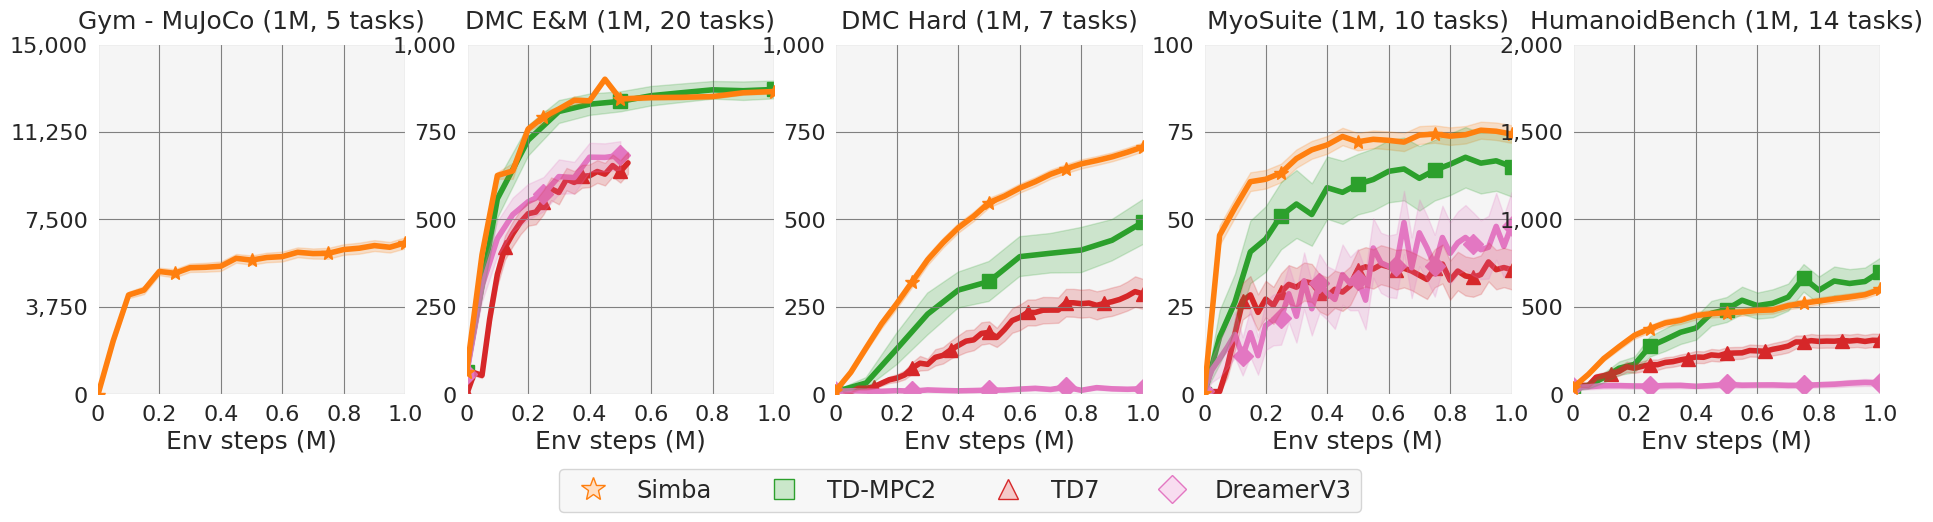

In [71]:
mujoco_eval_df = eval_df[eval_df['env_name'].isin(MUJOCO_ALL)]
dmc_easy_medium_eval_df = eval_df[eval_df['env_name'].isin(DMC_EASY_MEDIUM)]
dmc_hard_eval_df = eval_df[eval_df['env_name'].isin(DMC_HARD)]
myo_eval_df = eval_df[eval_df['env_name'].isin(MYOSUITE_TASKS)]
hb_eval_df = eval_df[eval_df['env_name'].isin(HB_LOCOMOTION_NOHAND)]
hb_eval_df = normalize_values(hb_eval_df, HB_SUCCESS_SCORE)

plot_multiple_environment_metrics(
    env_dfs=[mujoco_eval_df, dmc_easy_medium_eval_df, dmc_hard_eval_df, myo_eval_df, hb_eval_df],
    env_names=["Gym - MuJoCo", "DMC Easy-Medium", "DMC Hard", "MyoSuite", "HumanoidBench"],
    metrics=["avg_return", "avg_return", "avg_return", "avg_success", "avg_return"],
    colors=colors,
    x_lim_mins=[0, 0, 0, 0, 0],
    x_lim_maxs=[1.0e6, 1.0e6, 1.0e6, 1.0e6, 1.0e6],
    y_lim_mins=[0, 0, 0, 0, 0],
    y_lim_maxs=[15000, 1000, 1000, 100, 2000],
    y_labels=["Average Return", "Success Rate"],
    custom_titles=[
        "Gym - MuJoCo (1M, 5 tasks)",
        "DMC E&M (1M, 20 tasks)",
        "DMC Hard (1M, 7 tasks)",
        "MyoSuite (1M, 10 tasks)",
        "HumanoidBench (1M, 14 tasks)",
    ],
    num_x_ticks=6,
    line_width=4.0,
    plot_width= 23,
    plot_height= 4.8,
)

In [72]:
def plot_environment_metrics_per_env(
    env_dfs,
    env_names,
    env_dicts,
    colors,
    metrics,
    x_lim_mins,
    x_lim_maxs,
    y_lim_mins,
    y_lim_maxs,
    y_labels,
    plot_widths: list,
    plot_heights: list,
    plot_hspaces: list,
    plot_wspaces: list,
    legend_bbox_to_anchors: list,
    num_plots_per_row=4,
    num_x_ticks: int = 6,
    x_label: str = "Env steps (M)",
    line_width: float = 2.5
):
    for i, env_dict in enumerate(env_dicts):
        # indexing
        metric = metrics[i]
        x_lim_min, x_lim_max = x_lim_mins[i], x_lim_maxs[i]
        y_lim_min, y_lim_max = y_lim_mins[i], int(np.ceil(y_lim_maxs[i]))  # Round up to nearest integer
        y_label = y_labels[i]
        plot_width, plot_height = plot_widths[i], plot_heights[i]
        wspace, hspace = plot_wspaces[i], plot_hspaces[i]
        bbox_to_anchor = legend_bbox_to_anchors[i]
        env_df, env_name = env_dfs[i], env_names[i]
            
        num_plots = len(env_dict)
        ncols = min(num_plots_per_row, num_plots)
        nrows = (num_plots + ncols - 1) // ncols  # Calculate number of rows needed
        num_removes = ncols * nrows - num_plots 
        
        # Set up the figure
        sns.set_style('darkgrid', {"axes.facecolor": "whitesmoke", "grid.color": "gray"})
        # sns.set_style('whitegrid')    
        
        fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(plot_width, plot_height), squeeze=False)
        fig.subplots_adjust(hspace=hspace, wspace=wspace)
        axs = axs.flatten()  # Flatten in case of a single subplot
        
        for _elim_idx in range(1, num_removes+1):
            axs.flat[-1 * _elim_idx].set_visible(False) # # Remove empty subplots

        all_experiments = set()

        for j, env in enumerate(env_dict):
            ax = axs[j] # plot for env_name
            
            env_data = env_df[env_df["env_name"] == env]
            env_data = env_data[env_data["metric"] == metric]
            experiments = env_data["exp_name"].unique()
            
            # custom
            experiments = ['Simba', 'TD-MPC2', 'TD7', 'DreamerV3']
            
            all_experiments.update(experiments)

            for exp in experiments:
                exp_data = env_data[env_data["exp_name"] == exp]
                if len(exp_data) == 0:
                    continue
                
                num_seeds = exp_data["seed"].nunique()
                
                # Check if env_step = 0 exists, if not, add it with value 0
                if 0 not in exp_data["env_step"].values:
                    zero_row = pd.DataFrame({
                        "env_step": [0],
                        "value": [0],
                        "exp_name": [exp],
                        "metric": [metric]
                    })
                    exp_data = pd.concat([zero_row, exp_data]).reset_index(drop=True)
                    
                # Group by env_step and calculate mean across all environments
                grouped_data = exp_data.groupby(["env_step"])["value"]
                env_steps = grouped_data.mean().index.values
                mean = grouped_data.mean().values
                std_error = grouped_data.sem().values  # Standard error of the mean

                # Multiply by 10 for MyoSuite
                if env_name == "MyoSuite":
                    mean *= 100
                    std_error *= 100
                    y_lim_max = 100  # Set y_lim_max to 100 for percentage

                # Plot mean history with thicker lines
                from scipy.ndimage import convolve
                # mean = convolve(mean, [1/3,1/3,1/3])
                if exp == 'Simba':
                    zorder = 20
                elif exp == 'TD-MPC2':
                    zorder = 10
                elif exp == 'DreamerV3':
                    zorder = 0
                else:
                    zorder = -10
                timestep_list = [0, 2e5, 4e5, 6e5, 8e5, 1e6]
                ax.plot(env_steps, 
                        mean, 
                        label=exp, 
                        linewidth=line_width, 
                        color=colors[exp], 
                        marker=markers[exp], 
                        markevery=np.searchsorted(env_steps, 
                                                  [t for t in timestep_list if t <= max(env_steps)]),
                        markersize=8,
                        zorder=zorder)

                # Fill between mean - std_error and mean + std_error
                ax.fill_between(
                    env_steps,
                    mean - 1.96*std_error / math.sqrt(num_seeds),
                    mean + 1.96*std_error / math.sqrt(num_seeds),
                    alpha=0.2,
                    color=colors[exp],
                )
            
            # Set labels and limits
            ax.set_xlabel(x_label, fontsize=12)
            if j % num_plots_per_row == 0: 
                ax.set_ylabel(y_label, fontsize=12) # set ylabels for only leftmost subplots
            ax.set_xlim(x_lim_min, x_lim_max)
            ax.set_ylim(y_lim_min, y_lim_max)

            # Set x-ticks and format them
            x_ticks = np.linspace(x_lim_min, x_lim_max, num_x_ticks)
            ax.set_xticks(x_ticks)
            # Format x-tick labels
            x_tick_labels = []
            for tick in x_ticks:
                if tick == 0:
                    x_tick_labels.append("0")
                else:
                    x_tick_labels.append("{:.1f}".format(tick / 1e6))
            
            ax.set_xticklabels(x_tick_labels, fontsize=12)

            # Set y-ticks (only 3) and format them as integers
            y_ticks = np.linspace(y_lim_min, y_lim_max, 5, dtype=int)
            ax.set_yticks(y_ticks)
            #ax.set_xscale('log')
            ax.set_yticklabels(["{:,d}".format(int(tick)) for tick in y_ticks], fontsize=12)

            # Add custom title with first line bold
            title = env
            ax.set_title('')  # Clear any existing title
            ax.text(0.5, 1.03, title, transform=ax.transAxes, ha='center', va='bottom', fontsize=12, fontname='monospace', fontweight='bold')
            
            ax.set_autoscale_on(False)

        # Add shared legend below the subplots
        _, labels = ax.get_legend_handles_labels()
        plt.subplots_adjust(bottom=0.15)

        # Add markers to the legend
        handles = [legend_handles[k] for k in labels]
        fig.legend(handles, labels, loc='lower center', ncol=len(all_experiments), bbox_to_anchor=bbox_to_anchor, fontsize='xx-large')

        # Adjust layout and display
        plt.savefig(f"{env_name}_learning_curve.png",bbox_inches='tight')

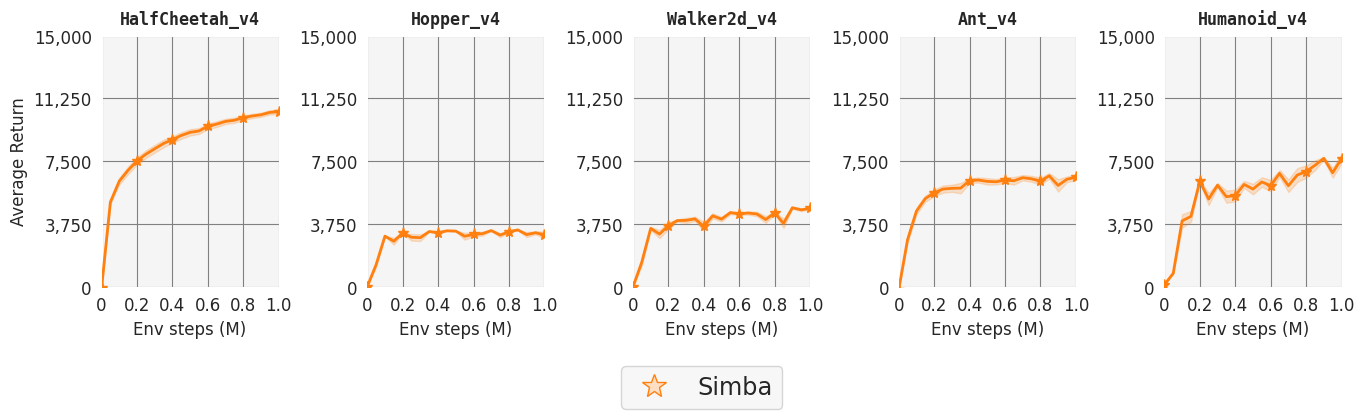

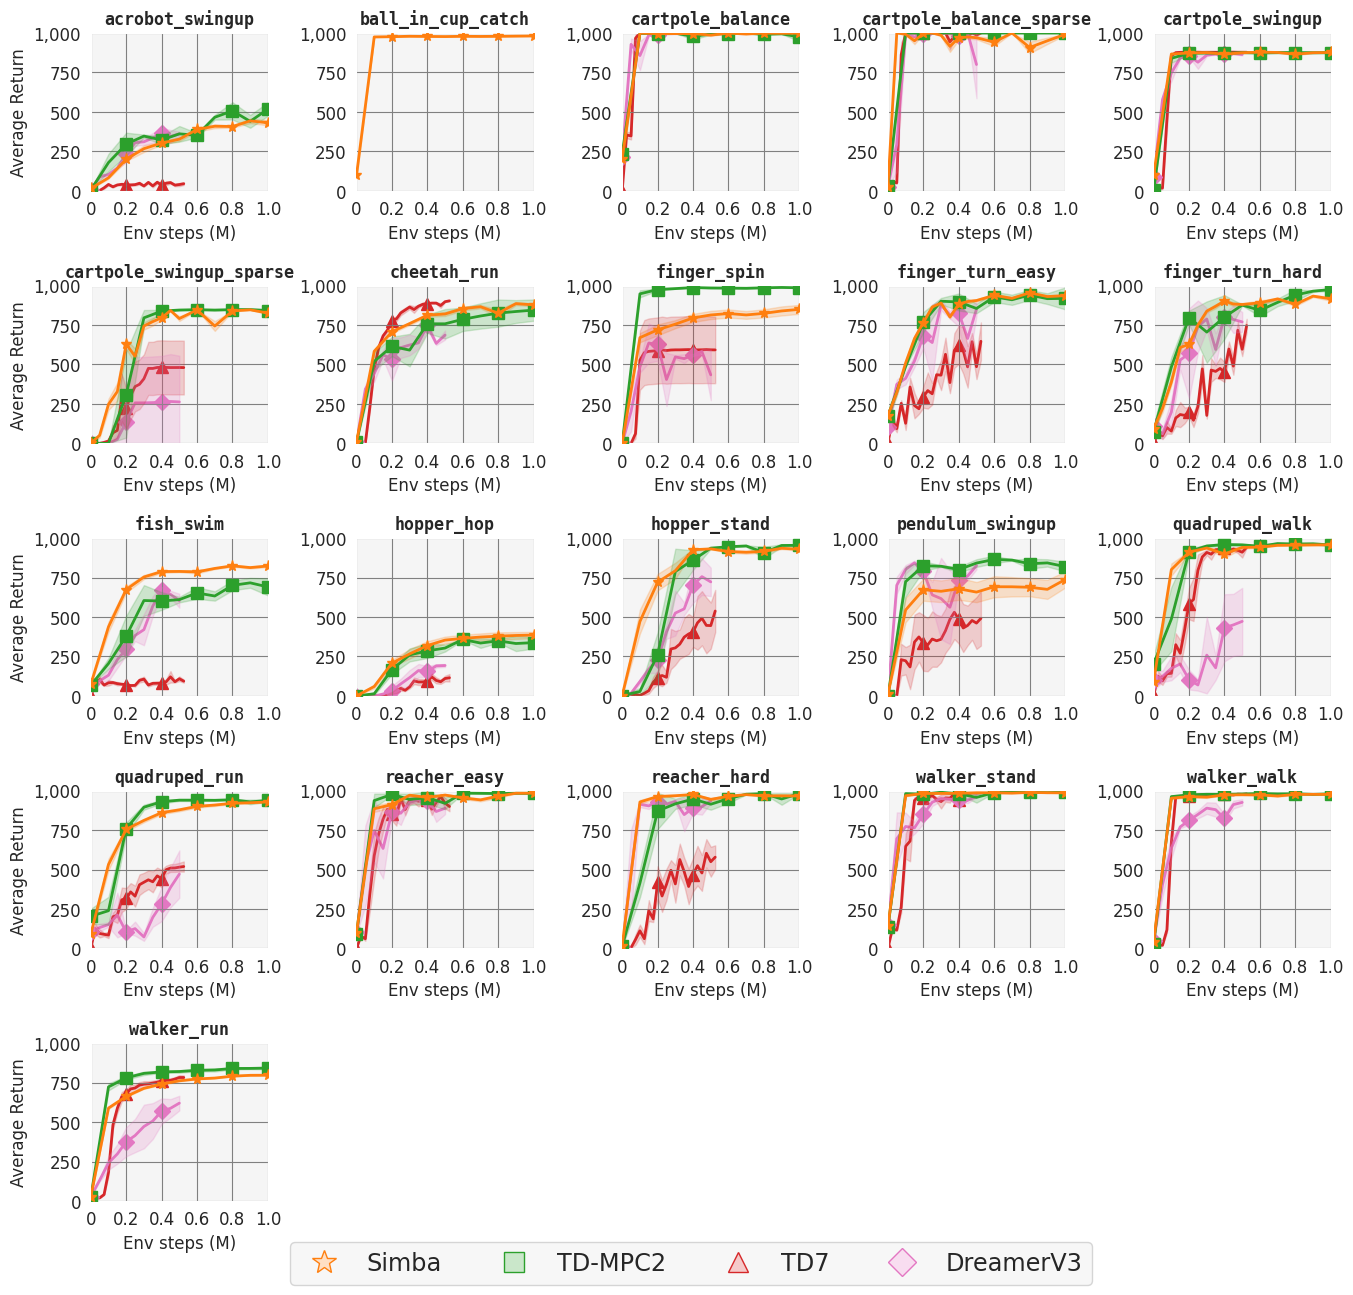

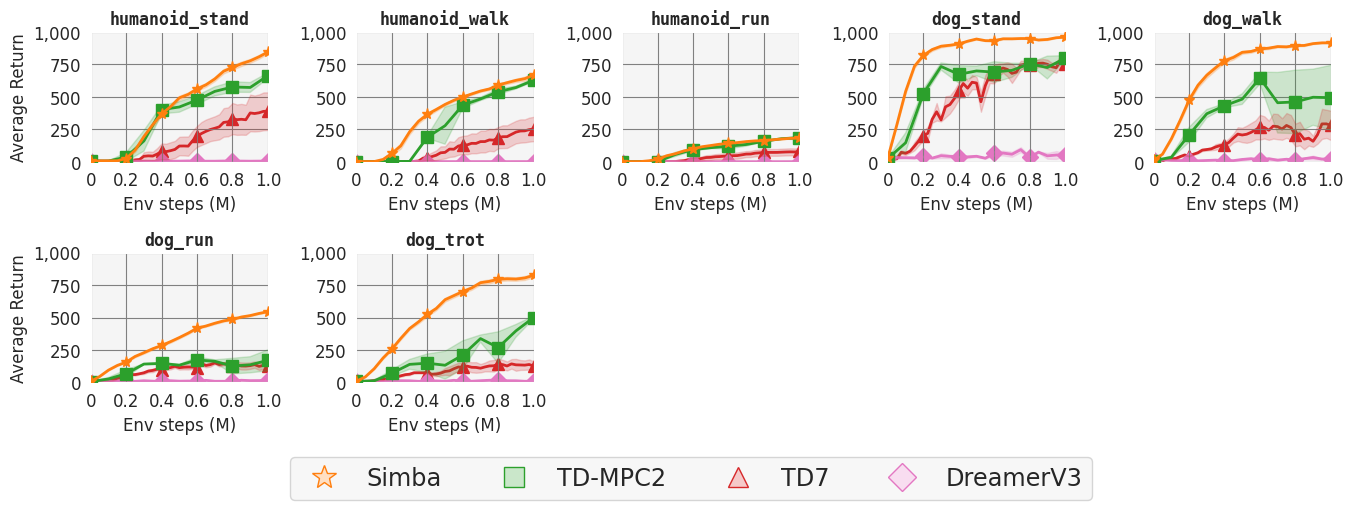

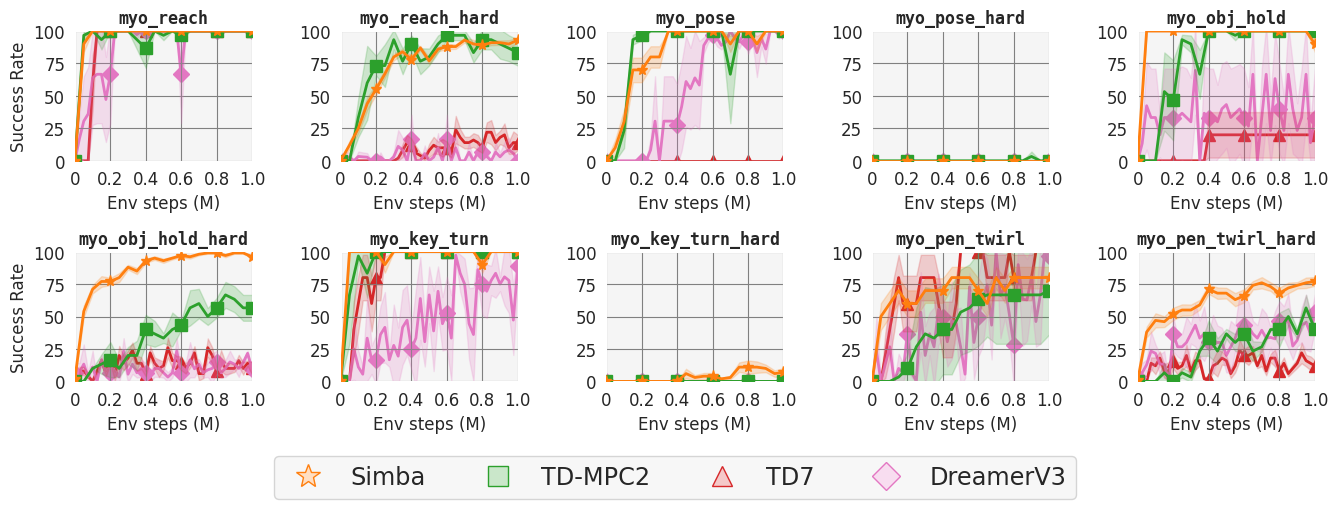

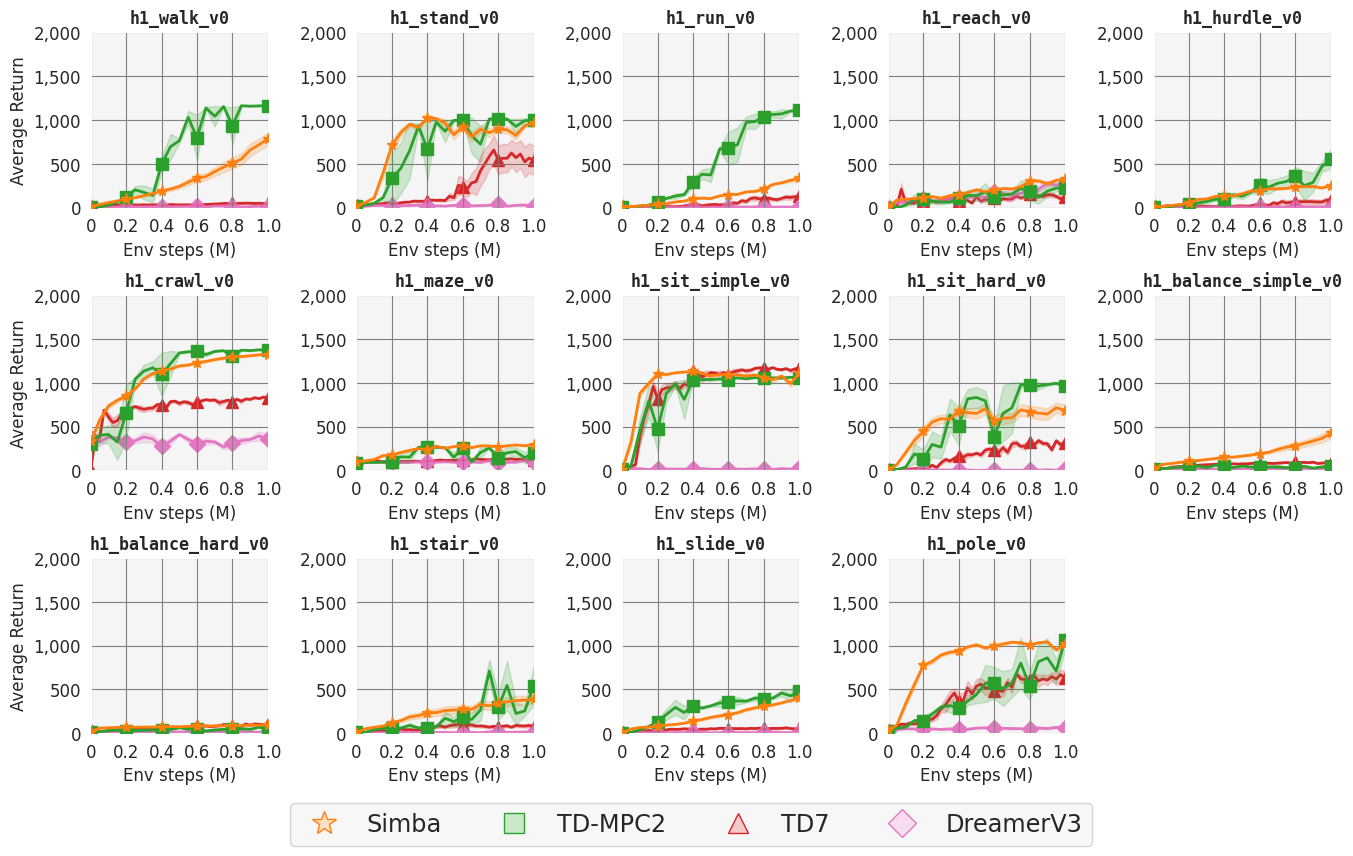

In [85]:
mujoco_eval_df = eval_df[eval_df['env_name'].isin(MUJOCO_ALL)]
dmc_easy_medium_eval_df = eval_df[eval_df['env_name'].isin(DMC_EASY_MEDIUM)]
dmc_hard_eval_df = eval_df[eval_df['env_name'].isin(DMC_HARD)]
myo_eval_df = eval_df[eval_df['env_name'].isin(MYOSUITE_TASKS)]
hb_eval_df = eval_df[eval_df['env_name'].isin(HB_LOCOMOTION_NOHAND)]
hb_eval_df = normalize_values(hb_eval_df, HB_SUCCESS_SCORE)

plot_environment_metrics_per_env(
    env_dfs=[mujoco_eval_df, dmc_easy_medium_eval_df, dmc_hard_eval_df, myo_eval_df, hb_eval_df],
    env_names=["Gym - MuJoCo", "DMC Easy-Medium", "DMC Hard", "MyoSuite", "HumanoidBench"],
    env_dicts=[MUJOCO_ALL, DMC_EASY_MEDIUM, DMC_HARD, MYOSUITE_TASKS, HB_LOCOMOTION_NOHAND],
    metrics=["avg_return", "avg_return", "avg_return", "avg_success", "avg_return"],
    colors=colors,
    x_lim_mins=[0, 0, 0, 0, 0],
    x_lim_maxs=[1.0e6, 1.0e6, 1.0e6, 1.0e6, 1.0e6],
    y_lim_mins=[0, 0, 0, 0, 0],
    y_lim_maxs=[15000, 1000, 1000, 100, 2000],
    y_labels=["Average Return", "Average Return", "Average Return", "Success Rate", "Average Return"],
    line_width=2.0,
    num_plots_per_row=5,
    plot_widths=[16.0, 16.0, 16.0, 16.0, 16.0],
    plot_heights=[3.44, 16.0, 4.8, 4.8, 9.6],
    plot_hspaces=[0.6, 0.6, 0.7, 0.7, 0.5],
    plot_wspaces=[0.5, 0.5, 0.5, 0.5, 0.5],
    legend_bbox_to_anchors=[(0.5, -0.24), (0.5, 0.09), (0.5, -0.12), (0.5, -0.12), (0.5, 0.02)]
)